In [2]:
import os
import pandas as pd

def merge_txt_files_to_dataset(input_folder, output_file, columns):
    all_data = []

    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            filepath = os.path.join(input_folder, filename)
            df = pd.read_csv(filepath, sep='\s+', header=None, names=columns)

            all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df.to_csv(output_file, index=False)
    print(f"Датасет сохранен в {output_file} (строк: {len(combined_df)})")

# Пример использования

merge_txt_files_to_dataset(
        input_folder='C:/Users/1/projects/zadachi/5 задача/K_E K_incl',  # Укажите путь к папке с .txt файлами
        output_file='K_E K_incl.csv',
        columns = ['K_E','K_incl_top_position_y', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z'])

Датасет сохранен в K_E K_incl.csv (строк: 500100)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
import pandas as pd
df = pd.read_csv('K_E K_incl.csv')

In [5]:
df

,K_E,K_incl_top_position_y,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,0.577465,0.792658,0.1,10.000000,5.331610e-13,5.331598e-13,0.25,5.000000e+10,2700,3582.255652,2068.216265,2502.294446
1,0.577465,0.792658,0.2,5.000000,5.334877e-13,5.331520e-13,0.25,5.000000e+10,2700,3582.255652,2068.216265,2502.294446
2,0.577465,0.792658,0.3,3.333333,5.364377e-13,5.361355e-13,0.25,5.000000e+10,2700,3582.255652,2068.216265,2502.294446
3,0.577465,0.792658,0.4,2.500000,5.339300e-13,5.318011e-13,0.25,5.000000e+10,2700,3582.255652,2068.216265,2502.294446
4,0.577465,0.792658,0.5,2.000000,5.366251e-13,5.267954e-13,0.25,5.000000e+10,2700,3582.255652,2068.216265,2502.294446
...,...,...,...,...,...,...,...,...,...,...,...,...
500095,1.856020,0.842554,9.6,0.104167,5.209662e-13,5.159948e-13,0.25,5.000000e+10,2700,6422.218378,3707.869509,2502.294446
500096,1.856020,0.842554,9.7,0.103093,5.216660e-13,5.165665e-13,0.25,5.000000e+10,2700,6422.218378,3707.869509,2502.294446
500097,1.856020,0.842554,9.8,0.102041,5.223356e-13,5.171145e-13,0.25,5.000000e+10,2700,6422.218378,3707.869509,2502.294446
500098,1.856020,0.842554,9.9,0.101010,5.229766e-13,5.176399e-13,0.25,5.000000e+10,2700,6422.218378,3707.869509,2502.294446


In [10]:
y = df[['K_E', 'K_incl_top_position_y']]
X = df[['A2', 'А2_surface']]

In [11]:
X

,A2,А2_surface
0,5.331610e-13,5.331598e-13
1,5.334877e-13,5.331520e-13
2,5.364377e-13,5.361355e-13
3,5.339300e-13,5.318011e-13
4,5.366251e-13,5.267954e-13
...,...,...
500095,5.209662e-13,5.159948e-13
500096,5.216660e-13,5.165665e-13
500097,5.223356e-13,5.171145e-13
500098,5.229766e-13,5.176399e-13


In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [8]:
def balanced_mse(y_true, y_pred):
        # Веса для разных параметров
        weights = tf.constant([1.0, 1.0], dtype=tf.float32)  # Равные веса
        
        # MSE для каждого параметра отдельно
        mse_per_param = tf.reduce_mean(tf.square(y_true - y_pred), axis=0)
        
        # Взвешенное среднее
        weighted_mse = tf.reduce_sum(weights * mse_per_param)
        
        return weighted_mse

def build_simple_keras():
    model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='linear')
    ])
    
    # Компиляция с оптимизацией всех параметров
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001,
    )
    
    model.compile(
        optimizer=optimizer,
        loss=balanced_mse
    )
    return model


In [9]:
print("\nОбучение Модели 2 (Keras Simple)...")
model_2 = build_simple_keras()
# epochs=100 - сколько раз сеть пройдет по всему датасету
# batch_size=32 - размер пакета данных за один шаг
# verbose=0 - скрывает лог обучения, чтобы не засорять вывод




Обучение Модели 2 (Keras Simple)...


In [10]:
history_2 = model_2.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - loss: 0.0017 - val_loss: 3.2069e-05
Epoch 2/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 4.7597e-05 - val_loss: 7.6547e-06
Epoch 3/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 3.2767e-05 - val_loss: 1.3666e-04
Epoch 4/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 2.7635e-05 - val_loss: 1.5009e-05
Epoch 5/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 2.4499e-05 - val_loss: 3.7869e-06
Epoch 6/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 2.1657e-05 - val_loss: 2.4013e-05
Epoch 7/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 1.9163e-05 - val_loss: 9.0022e-06
Epoch 8/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 1.6553e-05 - val_loss: 3.3680e-05
Epoch 9/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 1.6413e-05 - val_loss: 1.0632e-05
Epoch 10/100
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 1.5650e-05 - val_loss: 5.3057e-06
Epo

In [11]:
def build_deep_keras():
    model = Sequential()
    # Первый слой, побольше нейронов
    model.add(Dense(128, activation='relu'))
    # Dropout(0.2) выключает 20% нейронов случайно, чтобы сеть не запоминала данные наизусть
    model.add(Dropout(0.2))
    # Второй слой
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    # Третий слой
    model.add(Dense(32, activation='relu'))
    # Выходной слой
    model.add(Dense(2, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss=balanced_mse)
    return model

In [12]:
print("Обучение Модели 3 (Keras Deep)...")
model_3 = build_deep_keras()
history_3 = model_3.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)


Обучение Модели 3 (Keras Deep)...
Epoch 1/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0217 - val_loss: 0.0259
Epoch 2/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0083 - val_loss: 0.0276
Epoch 3/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0066 - val_loss: 0.0260
Epoch 4/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0054 - val_loss: 0.0284
Epoch 5/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0046 - val_loss: 0.0252
Epoch 6/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0041 - val_loss: 0.0239
Epoch 7/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0038 - val_loss: 0.0229
Epoch 8/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0036 - val_loss: 0.0248
Epoch 9/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0035 - val_loss: 0.0219
Epoch 10/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0033 - val_loss: 0.0246
Epoch 11/100
11253/11253 ━━━━━━━━━━━━━━━━━━━━

In [13]:

# Делаем предсказания (в масштабированном виде)
y_pred_2_scaled = model_2.predict(X_test)
y_pred_3_scaled = model_3.predict(X_test)

# Возвращаем предсказания в исходный масштаб (реальные физические величины)
y_pred_2 = scaler_y.inverse_transform(y_pred_2_scaled)
y_pred_3 = scaler_y.inverse_transform(y_pred_3_scaled)
# Также возвращаем реальные тестовые ответы в исходный масштаб для сравнения
y_test_real = scaler_y.inverse_transform(y_test)

3126/3126 ━━━━━━━━━━━━━━━━━━━━ 3s 790us/step
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step


In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def evaluate_model(y_true, y_pred, name):
    # R2 score (коэффициент детерминации): 1 - идеально, 0 - плохо
    r2_1 = r2_score(y_true[:, 0], y_pred[:, 0])
    r2_2 = r2_score(y_true[:, 1], y_pred[:, 1])
    print(f"Модель: {name} | R2_1: {r2_1:.4f} | R2_2: {r2_2:.4f}")
    return r2_1, r2_2

print("\n--- Результаты оценки ---")
r2_1, r2_2 = evaluate_model(y_test_real, y_pred_2, "Keras Simple NN")
r2_21, r2_22 = evaluate_model(y_test_real, y_pred_3, "Keras Deep NN + Dropout")


--- Результаты оценки ---
Модель: Keras Simple NN | R2_1: 1.0000 | R2_2: 1.0000
Модель: Keras Deep NN + Dropout | R2_1: 0.8786 | R2_2: 0.8511


C:\Users\1\AppData\Local\Temp\ipykernel_19040\2936658291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Simple Keras', 'Deep Keras'], y=[r2_1, r2_21], palette='viridis')
C:\Users\1\AppData\Local\Temp\ipykernel_19040\2936658291.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Simple Keras', 'Deep Keras'], y=[r2_2, r2_22], palette='viridis')


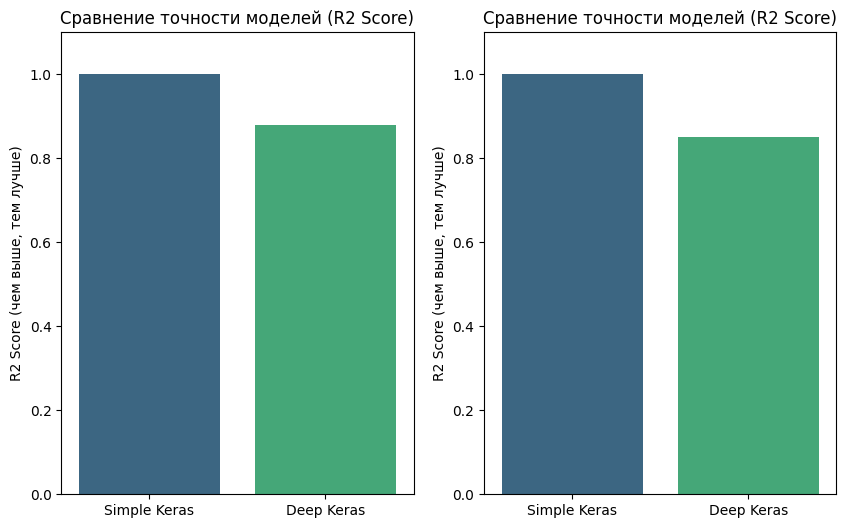

In [15]:

plt.figure(figsize=(10, 6))

# График 1: Сравнение метрики R2
models = ['Simple Keras', 'Deep Keras']
scores = [r2_1, r2_21]

plt.subplot(1, 2, 1)
sns.barplot(x=['Simple Keras', 'Deep Keras'], y=[r2_1, r2_21], palette='viridis')
plt.title('Сравнение точности моделей (R2 Score)')
plt.ylim(0, 1.1) # R2 максимум 1.0
plt.ylabel('R2 Score (чем выше, тем лучше)')

plt.subplot(1, 2, 2)
sns.barplot(x=['Simple Keras', 'Deep Keras'], y=[r2_2, r2_22], palette='viridis')
plt.title('Сравнение точности моделей (R2 Score)')
plt.ylim(0, 1.1) # R2 максимум 1.0
plt.ylabel('R2 Score (чем выше, тем лучше)')
plt.savefig('res1.png')


C:\Users\1\AppData\Local\Temp\ipykernel_19040\356169545.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test_real[:, 0].min(), y_test_real[:, 0].max()],
C:\Users\1\AppData\Local\Temp\ipykernel_19040\356169545.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test_real[:, 1].min(), y_test_real[:, 1].max()],


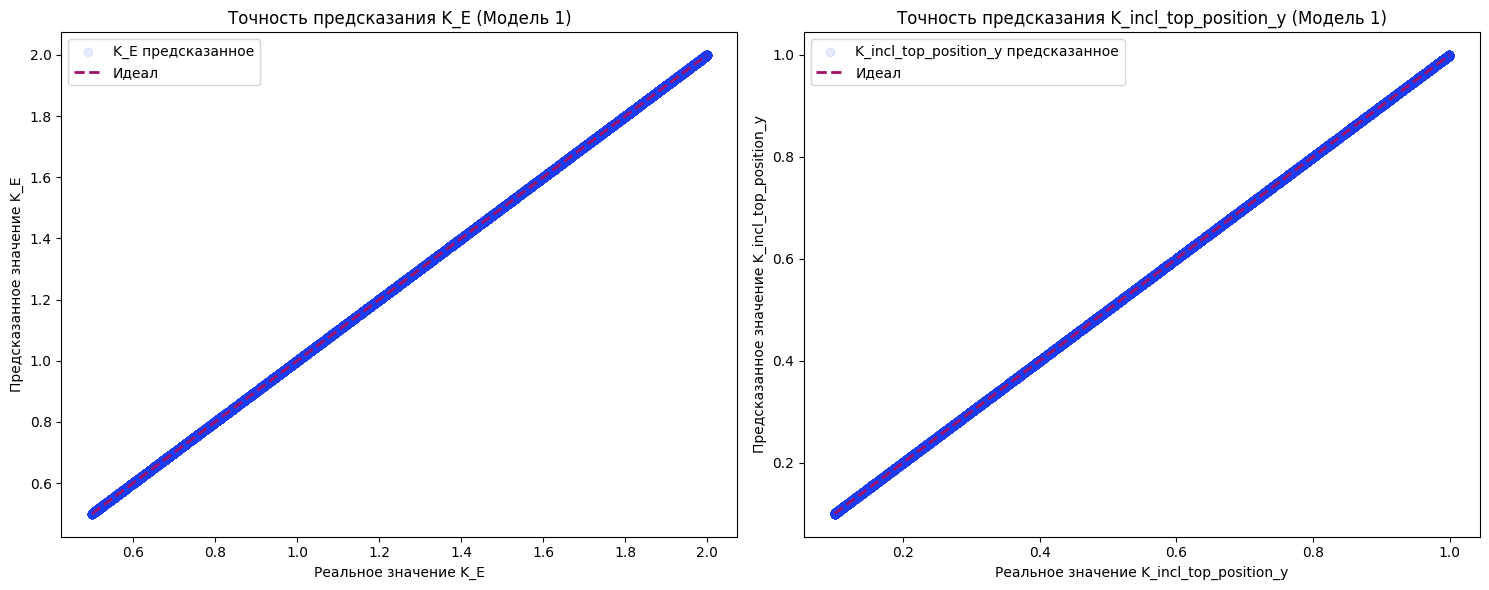

In [16]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test_real[:, 0], y_pred_2[:, 0], alpha=0.1, color='#1a3cee', label='K_E предсказанное')
# Рисуем идеальную диагональ
plt.plot([y_test_real[:, 0].min(), y_test_real[:, 0].max()], 
         [y_test_real[:, 0].min(), y_test_real[:, 0].max()], 'r--', lw=2, color='#a10f69', label='Идеал')
plt.xlabel('Реальное значение K_E')
plt.ylabel('Предсказанное значение K_E')
plt.title(f'Точность предсказания K_E (Moдель 1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_real[:, 1], y_pred_2[:, 1], alpha=0.1, color='#1a3cee', label='K_incl_top_position_y предсказанное')
# Рисуем идеальную диагональ
plt.plot([y_test_real[:, 1].min(), y_test_real[:, 1].max()], 
         [y_test_real[:, 1].min(), y_test_real[:, 1].max()], 'r--', color='#a10f69', lw=2, label='Идеал')
plt.xlabel('Реальное значение K_incl_top_position_y')
plt.ylabel('Предсказанное значение K_incl_top_position_y')
plt.title('Точность предсказания K_incl_top_position_y (Модель 1)')
plt.legend()
plt.savefig('res3.png')
plt.tight_layout()
plt.show()
